<a href="https://colab.research.google.com/github/SLP-AI-2025/Stock-Prediction/blob/ml-team/StockPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


1) **Setup**
2) **Data Team** → download & features → `features.csv`
3) **ML Team** → train Logistic Regression → `predictions.json`, `metrics.json`
4) **Visualization Team** → plots from predictions

> If stuck: read the **Hints** under each TODO. When done with a step, run the **Checkpoint** cell.


In [ ]:
# =============================
# 📦 Setup (run this first)
# =============================
# If on Colab, uncomment to install:
#!pip install yfinance pandas numpy scikit-learn matplotlib --quiet

import pandas as pd, numpy as np
from matplotlib import pyplot as plt
import json, os

print("Setup complete — pandas", pd.__version__)

Setup complete — pandas 2.2.2


In [ ]:
TICKERS = ['AAPL', 'MSFT', 'SPY']
YEARS = 5
TRAIN_TEST_SPLIT_DATE = '2024-01-01'
THRESHOLD_UP = 0.55

FEATURES_CSV = 'features.csv'
PREDICTIONS_JSON = 'predictions.json'
METRICS_JSON = 'metrics.json'

print("TICKERS:", TICKERS)

TICKERS: ['AAPL', 'MSFT', 'SPY']


---
# Data Section (Team 1)

**Goal:** Download daily prices, compute simple indicators, create the label (`target`: 1 if tomorrow up, 0 if down), and save `features.csv`.

You will fill several **TODOs**. Follow hints and run checkpoints.


### Step 1 — Download OHLCV (Close & Volume) for each ticker
- Use **yfinance** to grab last `YEARS` years of daily data.
- Keep columns: `Date`, `close`, `volume`, `ticker`.


In [14]:
# Example pattern shown, but you must complete TODOs.
import yfinance as yf

def download_ohlcv(ticker: str, years: int):
     # TODO: use yf.download to fetch daily data
   # df= yf.download(ticker, period=f'{years}y', interval='1d')

    df = yf.download(
        ticker,
        period=f'{years}y',
        interval='1d',
        auto_adjust=True,
        group_by='column'
    )
    # TODO: keep only Close and Volume, rename to 'close', 'volume'
    df = df[['Close', 'Volume']]
    df.columns = ['close', 'volume']
    # TODO: reset index so Date becomes a column
    # reset index so Date becomes a column
    df = df.reset_index()

    # TODO: add a 'ticker' column with the ticker string
    df['ticker'] = ticker

    return df

# Build raw dict (you can print head() to inspect)
raw = {t: download_ohlcv(t, YEARS) for t in TICKERS}
raw['AAPL'].head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Date,close,volume,ticker
0,2020-10-22,112.592102,101988000,AAPL
1,2020-10-23,111.901459,82572600,AAPL
2,2020-10-26,111.911171,111850700,AAPL
3,2020-10-27,113.418907,92276800,AAPL
4,2020-10-28,108.166199,143937800,AAPL


In [15]:
# Checkpoint: basic sanity
assert len(raw) == len(TICKERS), "raw should have one DataFrame per ticker"
sample_key = list(raw.keys())[0]
for t, df in raw.items():
    assert {'Date','close','volume','ticker'}.issubset(df.columns), f"Missing columns in {t}"
print("✅ Step 1 OK — downloads look fine.")

✅ Step 1 OK — downloads look fine.


### Step 2 — Compute simple indicators (features)
Create: **sma_5**, **sma_20**, **rsi_14** (simple proxy), **ret_1d**, **vol_10**.


In [16]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    # TODO: Simple Moving Averages (rolling mean)
    out['sma_5']  = out['close'].rolling(5).mean()
    out['sma_20'] = out['close'].rolling(20).mean()
    # TODO: RSI-like momentum proxy
    # HINT: r = pct_change; up = positive rolling mean; dn = abs(negative) rolling mean; RSI = 100 - 100/(1+up/dn)
    r = out['close'].pct_change()
    up = r.clip(lower=0).rolling(14).mean()
    dn = (-r.clip(upper=0)).rolling(14).mean()
    rs = up / (dn + 1e-9)
    out['rsi_14'] = 100 - (100/(1+rs))
    # TODO: 1-day return and 10-day rolling std of returns
    out['ret_1d'] = r
    out['vol_10'] = r.rolling(10).std()
    return out

feat_list = [add_features(raw[t]) for t in TICKERS]
features = pd.concat(feat_list, ignore_index=True)
features.head(3)

,Date,close,volume,ticker,sma_5,sma_20,rsi_14,ret_1d,vol_10
0,2020-10-22,112.592102,101988000,AAPL,NaN,NaN,NaN,NaN,NaN
1,2020-10-23,111.901459,82572600,AAPL,NaN,NaN,NaN,-0.006134,NaN
2,2020-10-26,111.911171,111850700,AAPL,NaN,NaN,NaN,0.000087,NaN


### Step 3 — Create the label (`target`)
- `next_close = close` shifted **backward by 1 day per ticker**  
- `target = 1` if `next_close > close` else `0`


In [17]:
# TODO: Create next_close per ticker with groupby().shift(-1)
features['next_close'] = features.groupby('ticker')['close'].shift(-1)
# TODO: Binary label
features['target'] = (features['next_close'] > features['close']).astype(int)

# Drop NaNs from rolling windows
features = features.dropna().reset_index(drop=True)

# Keep only the needed columns in a clean table called features_ready
keep_cols = ['Date','ticker','close','sma_5','sma_20','rsi_14','ret_1d','vol_10','next_close','target']
features_ready = features[keep_cols]
features_ready.head(3)

,Date,ticker,close,sma_5,sma_20,rsi_14,ret_1d,vol_10,next_close,target
0,2020-11-18,AAPL,115.007942,116.185023,112.811444,56.194386,-0.011391,0.017548,115.602348,1
1,2020-11-19,AAPL,115.602348,116.073946,112.961957,74.675246,0.005168,0.013440,114.335625,0
2,2020-11-20,AAPL,114.335625,115.699777,113.083665,70.749610,-0.010958,0.013878,110.934975,0


In [18]:
# Checkpoint: columns and nulls
assert set(keep_cols).issubset(features_ready.columns), "Missing expected columns."
assert features_ready.isna().sum().sum() == 0, "There should be no NaNs after cleaning."
print("✅ Data ready:", features_ready.shape)

✅ Data ready: (3705, 10)


### Step 4 — Save for ML team
Write `features.csv` that the ML team will use.


In [19]:
# TODO: Save features_ready to CSV
features_ready.to_csv(FEATURES_CSV, index=False)
print(f"✅ Wrote {FEATURES_CSV} to", os.getcwd())

✅ Wrote features.csv to /content


---
# ML Section (Team 2)

**Goal:** Train **Logistic Regression** to predict `target`.  
Output metrics and export `predictions.json` + `metrics.json` for the Viz team.


### Step 1 — Load features and split by date
- Use `TRAIN_TEST_SPLIT_DATE` to separate train vs. test.
- Features: `['sma_5','sma_20','rsi_14','ret_1d','vol_10']`


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# TODO: load the CSV; parse Date - Done
df = pd.read_csv(FEATURES_CSV, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)


feats = ['sma_5','sma_20','rsi_14','ret_1d','vol_10']
target = 'target'

# TODO: date-based split (avoid leakage) - Done
train = df[df['Date'] < TRAIN_TEST_SPLIT_DATE].copy()
test  = df[df['Date'] >= TRAIN_TEST_SPLIT_DATE].copy()

assert train['Date'].max() < test['Date'].min(), "Train-test dates overlap"

Xtr, ytr = train[feats], train[target]
Xte, yte = test[feats],  test[target]

scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)

print("Train/Test sizes:", Xtr.shape, Xte.shape)

Train/Test sizes: (2349, 5) (1356, 5)


### Step 2 — Train & Evaluate
- Use `LogisticRegression(class_weight='balanced', max_iter=1000)`  
- Print accuracy and `classification_report`  
- Save probability of "up" for test set


In [23]:
# TODO: create and fit the model - Done
model = LogisticRegression(class_weight='balanced', max_iter=1000, solver = 'liblinear', random_state = 42)
model.fit(Xtr, ytr)

# TODO: predicted probabilities of class 1 (up) - Done
proba_up = model.predict_proba(Xte)[:,1]
pred_up = (proba_up > 0.5).astype(int)

acc = accuracy_score(yte, pred_up)
print("Accuracy:", round(acc,3))
print(classification_report(yte, pred_up, digits=3))

# Optional: simple edge metric - Done
test = test.copy()
test['proba_up'] = proba_up
test['pred_up'] = pred_up
test['next_ret'] = test['next_close']/test['close'] - 1
edge = float(test.loc[test['pred_up']==1, 'next_ret'].mean())
print("Avg next-day return when predicting UP:", round(edge,5))

Accuracy: 0.494
              precision    recall  f1-score   support

           0      0.447     0.593     0.510       602
           1      0.561     0.415     0.477       754

    accuracy                          0.494      1356
   macro avg      0.504     0.504     0.494      1356
weighted avg      0.511     0.494     0.492      1356

Avg next-day return when predicting UP: 0.00128


### Step 3 — Export recent predictions & metrics
- For each ticker, take the **last 60 rows** (most recent).  
- Save `[{{Date, ticker, close, proba_up, signal}}]` to `predictions.json`  
- Save metrics dict to `metrics.json`


In [24]:
# TODO: create a 'signal' using THRESHOLD_UP - Done
test['signal'] = (test['proba_up'] > THRESHOLD_UP).map(lambda b: 'buy' if b else 'neutral')

# Recent window per ticker
recent = (test.sort_values(['ticker','Date'])
               .groupby('ticker')
               .tail(60)
               [['Date','ticker','close','proba_up','signal']]
               .copy())
recent['Date'] = recent['Date'].dt.strftime('%Y-%m-%d')

with open(PREDICTIONS_JSON, 'w') as f:
    json.dump(recent.to_dict(orient='records'), f, indent=2)

with open(METRICS_JSON, 'w') as f:
    json.dump({"accuracy": float(acc), "avg_next_day_return_when_buy": edge}, f, indent=2)

print(f"✅ Wrote {PREDICTIONS_JSON} & {METRICS_JSON}")

✅ Wrote predictions.json & metrics.json


---
# Visualization Section (Team 3)

**Goal:** Plot a clean chart of price with markers where `signal == 'buy'` for each ticker.


### Step 1 — Load predictions & metrics


In [25]:
# TODO: read predictions.json and metrics.json
preds = pd.read_json(PREDICTIONS_JSON)
preds['Date'] = pd.to_datetime(preds['Date'])

with open(METRICS_JSON) as f:
    metrics = json.load(f)
print("Metrics:", metrics)

Metrics: {'accuracy': 0.4941002949852507, 'avg_next_day_return_when_buy': 0.0012761966934348703}


### Step 2 — Plot price + buy markers
- Use Matplotlib line for price and scatter for buy markers.
- Add title, labels, legend.


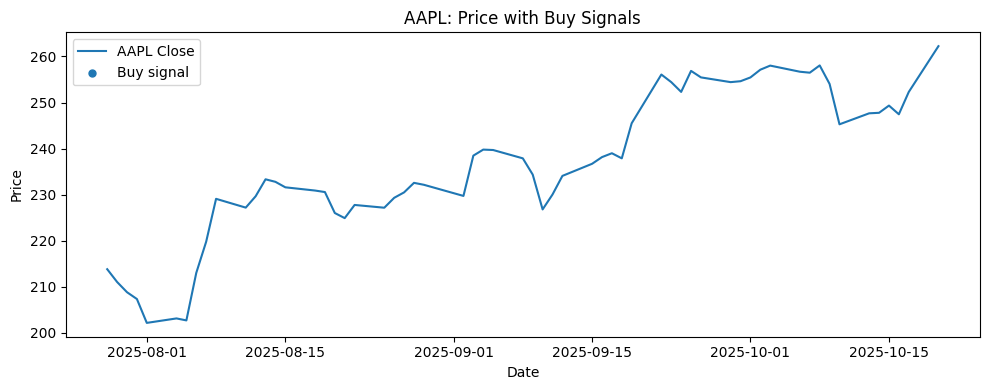

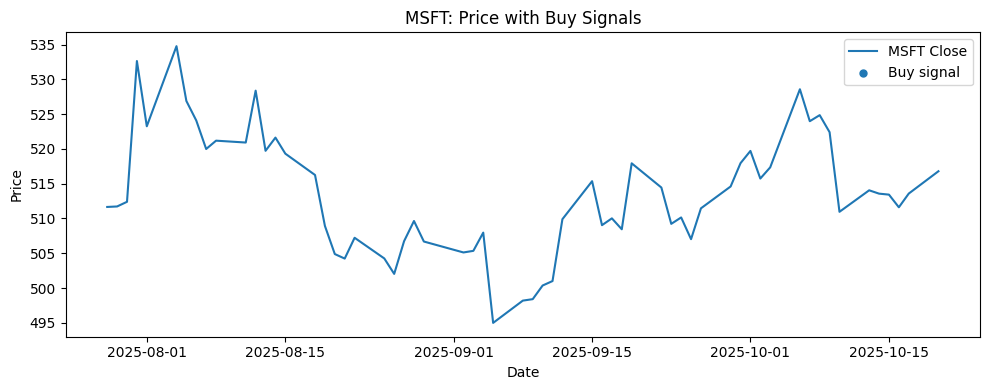

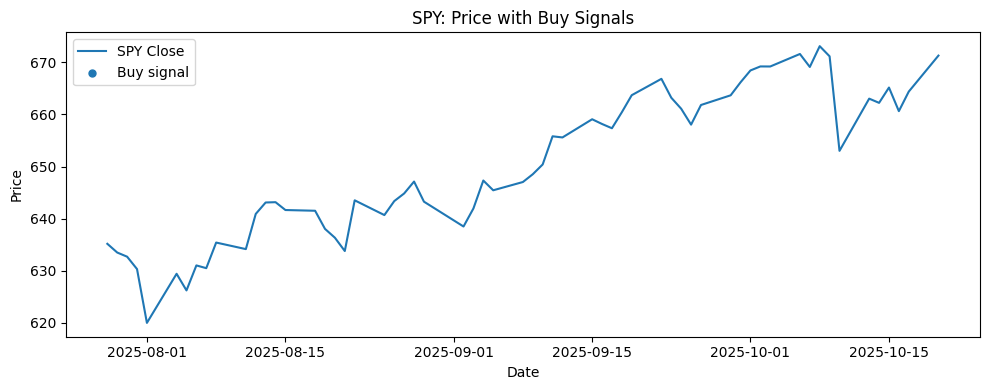

In [26]:
def plot_ticker(ticker: str):
    d = preds[preds['ticker']==ticker].sort_values('Date')
    # TODO: price line
    plt.figure(figsize=(10,4))
    plt.plot(d['Date'], d['close'], label=f'{ticker} Close')
    # TODO: buy markers
    buy_mask = d['signal']=='buy'
    plt.scatter(d.loc[buy_mask,'Date'], d.loc[buy_mask,'close'], label='Buy signal', s=25)
    # Decor
    plt.title(f'{ticker}: Price with Buy Signals')
    plt.xlabel('Date'); plt.ylabel('Price'); plt.legend(); plt.tight_layout()
    plt.show()

# TODO: loop through unique tickers
for t in preds['ticker'].unique():
    plot_ticker(t)

---
## End-of-Week Checklist
- **Data Team:** `features.csv` exists, no NaNs, correct columns.
- **ML Team:** Printed accuracy; exported `predictions.json` & `metrics.json`.
- **Viz Team:** Plots show price with clear buy markers.
